# ANÁLISIS DESCRIPTIVO

En este notebook se realizará el análisis descriptivo de cada variable presente en el conjunto de datos `temporada1.parquet`.

El objetivo de esta etapa es conocer la estructura y las características generales de los datos, identificar posibles valores faltantes o inconsistencias y obtener una primera aproximación a la distribución de las variables de interés.

In [1]:
# Cargamos los paquetes necesarios
import matplotlib.pyplot as plt 
import polars as pl
import seaborn as sns

import pyprojroot

from plotnine import *

In [2]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento = pl.read_parquet(ROOT / "datos" / "temporada1.parquet")

Completada la carga de los datos, se visualizarán las primeras 10 filas del conjunto de datos. Posteriormente, se procederá a explorar sus características generales.

In [4]:
datos_entrenamiento.head(10)

pitch_id,release_speed,batter,pitcher,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
i64,f64,i64,i64,str,str,str,str,i64,i64,f64,f64,f64,f64,f64,f64
2697762,93.800003,5782,5738,"""ball""","""R""","""R""","""SI""",1,1,-0.98,0.72,-1.23,4.1,3.7,1.82
2697773,95.599998,5782,5738,"""foul""","""R""","""R""","""FF""",3,2,-0.38,0.96,-0.45,3.1,3.41,1.56
2697902,94.800003,5782,5842,"""foul""","""R""","""R""","""FF""",1,0,-0.62,1.16,0.31,2.4,3.41,1.56
2697993,87.300003,5782,5041,"""ball""","""R""","""R""","""SL""",2,1,0.82,-0.06,1.11,2.21,3.7,1.73
2697995,98.599998,5782,5041,"""called_strike""","""R""","""R""","""FF""",3,1,-0.33,0.95,-0.35,3.39,3.7,1.7
2697997,98.900002,5782,5041,"""foul""","""R""","""R""","""FF""",3,2,-0.42,0.89,-0.75,2.76,3.41,1.56
2697712,95.400002,5782,5738,"""foul""","""R""","""R""","""FF""",0,0,-0.58,0.98,-0.16,2.36,3.41,1.56
2697720,87.400002,5782,5738,"""ball""","""R""","""R""","""SL""",0,1,0.24,0.15,-0.25,3.97,3.61,1.79
2697768,87.199997,5782,5738,"""called_strike""","""R""","""R""","""SL""",2,1,0.16,0.24,-0.54,3.09,3.64,1.7


### Análisis Univariado

A continuación, se presenta el análisis univariado de las variables presentes en la base de datos, describiendo individualmente sus principales características.

En primer lugar, se analizan las variables cuantitativas de la base de datos. Para ello, se calculan medidas descriptivas de tendencia central, dispersión y posición, tales como la media, mediana, desvío estándar, cuartiles y valores extremos. Estas medidas permiten resumir las principales características de cada variable y comprender su comportamiento general.

In [ ]:
# Se seleccionan las variables cuantitativas del conjunto de datos
variables_cuantitativas = datos_entrenamiento.select([
    "release_speed",
    "balls",
    "strikes",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot"
])

# Se arma una tabla resumen, la cual presenta las medidas descriptivas para cada variable cuantitativa
tabla_resumen = variables_cuantitativas.describe()

# Se renombran las medidas descriptivas
tabla_resumen = tabla_resumen.with_columns(
    pl.col("statistic").replace({
        "count": "Cantidad",
        "null_count": "Nulos",
        "mean": "Media",
        "std": "Desvío",
        "min": "Mínimo",
        "25%": "Q1",
        "50%": "Mediana",
        "75%": "Q3",
        "max": "Máximo"
    })
)

tabla_resumen = tabla_resumen.rename({
    "statistic": "Medida"
})

# Se muestra la tabla resumen
tabla_resumen


Medida,release_speed,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Cantidad""",709485.0,709852.0,709852.0,706819.0,708792.0,709485.0,709452.0,709485.0,709440.0
"""Nulos""",367.0,0.0,0.0,3033.0,1060.0,367.0,400.0,367.0,412.0
"""Media""",88.848689,0.883648,0.895387,-0.10355,0.65788,0.043603,2.275044,3.391976,1.57385
"""Desvío""",6.050308,0.968486,0.828389,0.866855,0.747155,0.846102,0.984652,0.164649,0.089665
"""Mínimo""",30.1,0.0,0.0,-2.56,-2.13,-6.1,-5.07,2.5,0.77
"""Q1""",84.599998,0.0,0.0,-0.83,0.2,-0.53,1.64,3.3,1.51
"""Mediana""",89.900002,1.0,1.0,-0.17,0.76,0.04,2.28,3.41,1.56
"""Q3""",93.699997,2.0,2.0,0.59,1.28,0.61,2.92,3.49,1.62
"""Máximo""",103.400002,4.0,2.0,2.84,2.58,9.11,9.39,4.47,2.26


A partir de las medidas descriptivas obtenidas, se puede notar que, la velocidad de lanzamiento (`release_speed`) presenta una dispersión moderada, mientras que la cercanía entre la media y la mediana podría indicar una distribución relativamente simétrica. Las variables `balls` y `strikes`, correspondientes al conteo de bolas y strikes, presentan medianas iguales a 1, lo que indica que los lanzamientos suelen registrarse en conteos bajos. Por otro lado, las variables relacionadas con el movimiento y la ubicación de la pelota (`pfx_x`, `pfx_z`, `plate_x` y `plate_z`) presentan una mayor variabilidad, reflejando la diversidad de trayectorias observadas en los lanzamientos. En contraste, los límites de la zona de strike (`sz_top` y `sz_bot`) muestran una dispersión reducida, evidenciando mediciones más homogéneas entre las observaciones analizadas.

Además, se observa la presencia de valores faltantes en varias de las variables continuas, siendo `pfx_x` la que registra la mayor cantidad de datos ausentes, mientras que `balls` y `strikes` las unicas que no presentan valores nulos.

Además se agregaran histogramas para cada variable, asi poder apreciar mejor la distribución de las mismas.

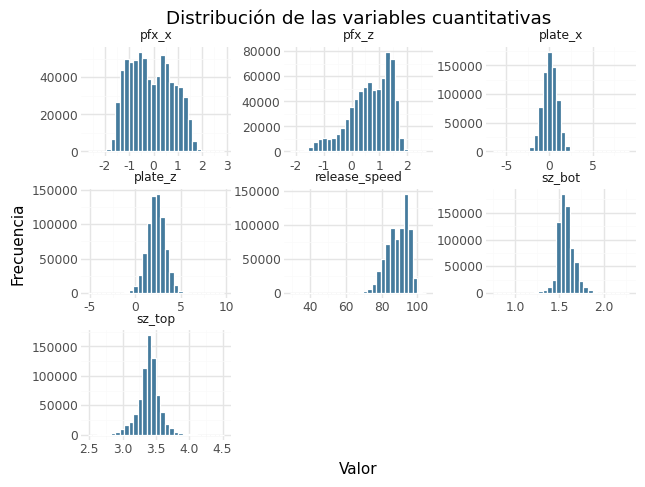

In [ ]:
# Se seleccionan las variables continuas
datos_continuos = variables_cuantitativas.drop(["balls", "strikes"])

# 
datos_long = (
    datos_continuos
    .to_pandas()
    .melt(
        var_name="Variable",
        value_name="Valor"
    )
    .dropna()
)

# Panel de gráficos para las variables cuantitativas continuas
(
    ggplot(datos_long, aes(x="Valor"))
    + geom_histogram(
        bins=30,
        fill="#2A9D8F",
        color="white"
    )
    + facet_wrap("~Variable", scales="free")
    + labs(
        title="Distribución de las variables cuantitativas",
        x="Valor",
        y="Frecuencia"
    )
    + theme_minimal()
)

Del panel de gráficos anterior se puede observar que las variables `plate_x`, `plate_z`, `sz_bot` y `sz_top` presentan distribuciones aproximadamente simétricas. Por otro lado, la variable `release_speed` parece exhibir una ligera asimetría a la izquierda, lo que contrasta con lo sugerido inicialmente por las medidas descriptivas, donde la cercanía entre la media y la mediana hacía pensar en una distribución más simétrica. Asimismo, la variable `pfx_z` presenta una distribución asimétrica a la izquierda, evidenciando además la presencia de valores extremos más notorios. Finalmente, la variable `pfx_x` muestra una distribución más dispersa y relativamente equilibrada alrededor de su centro, sin una asimetría marcada en ninguna dirección.

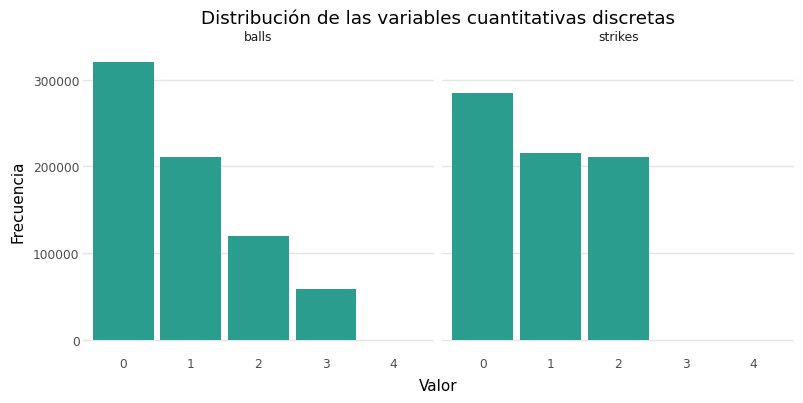

In [37]:
# Se seleccionan las variables discretas 
datos_discretos = (
    variables_cuantitativas
    .select(["balls", "strikes"])
    .to_pandas()
    .melt(
        var_name="Variable",
        value_name="Valor"
    )
    .dropna()
)

# Panel de gráficos para las variables cuantitativas discretas
(
    ggplot(datos_discretos,
           aes(x="factor(Valor)"))
    + geom_bar(fill="#2A9D8F")
    + facet_wrap("~Variable")
    + labs(
        title="Distribución de las variables cuantitativas discretas",
        x="Valor",
        y="Frecuencia"
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor=element_blank()
    )
)

A partir de los gráficos de barras se observa que ambas variables presentan una mayor concentración de observaciones en los valores más bajos. En particular, para la variable `balls` la frecuencia disminuye a medida que aumenta el número de bolas acumuladas, siendo el valor 0 el más frecuente. Por su parte, la variable `strikes` también presenta una mayor frecuencia en el valor 0, aunque los valores 1 y 2 exhiben frecuencias similares entre sí.

Para las variables cualitativas se examinó la distribución de frecuencias de cada categoría mediante tablas y representaciones gráficas. Esto permite obtener una visión general de la composición de la muestra y de la frecuencia relativa de cada nivel observado.

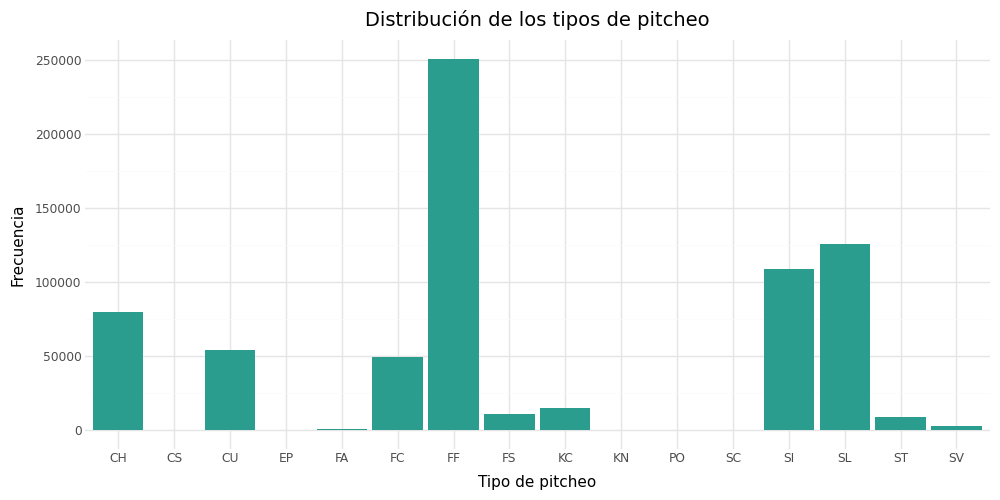

In [29]:
# Se filtra la variable tipo de pitcheo
freq_pitch = (
    datos_entrenamiento
    .filter(pl.col("pitch_type").is_not_null())
    .group_by("pitch_type")
    .len()
    .sort("pitch_type")
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(freq_pitch,
           aes(x="pitch_type", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Distribución de los tipos de pitcheo",
        x="Tipo de pitcheo",
        y="Frecuencia"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 5),
        axis_text_x=element_text(rotation=0),
        plot_title=element_text(size=14)
    )
)

En el gráfico se observa una marcada diferencia entre las frecuencias de las distintas categorías del tipo de pitcheo (`pitch_type`), lo que evidencia un uso desigual de los tipos de lanzamiento. En particular, las categorías `FF`, `SI` y `SL` concentran la mayor cantidad de observaciones, sugiriendo que son los lanzamientos más utilizados. En contraste, el resto de las categorías presenta frecuencias considerablemente menores, lo que indicaría que corresponden a situaciones menos frecuentes dentro del juego.

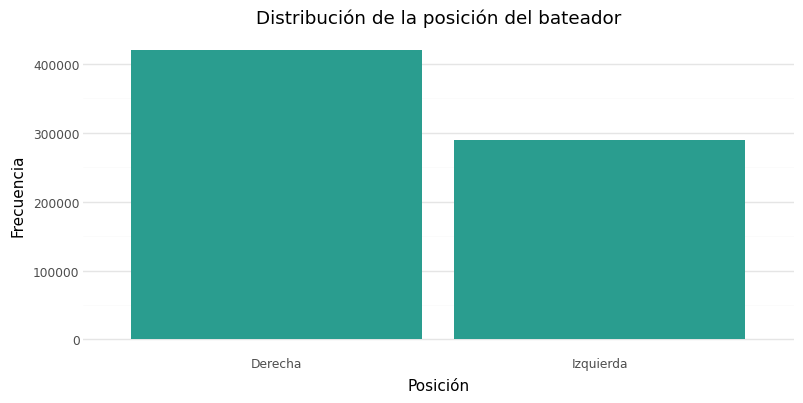

In [28]:
# Se filtra la variable posición del bateador
freq_stand = (
    datos_entrenamiento
    .filter(pl.col("stand").is_not_null())
    .group_by("stand")
    .len()
    .sort("stand")
    .to_pandas()
)

# Se renombran las categorias solo para el gráfico
freq_stand["stand"] = freq_stand["stand"].replace({
    "L": "Izquierda",
    "R": "Derecha"
})

# Se arma el gráfico
(
    ggplot(freq_stand,
           aes(x="stand", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Distribución de la posición del bateador",
        x="Posición",
        y="Frecuencia"
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank()
    )
)

Para la variable posición de bateo (`stand`), se observa que la categoría derecha es la más frecuente dentro del conjunto de datos, concentrando una mayor cantidad de observaciones que la posición izquierda.

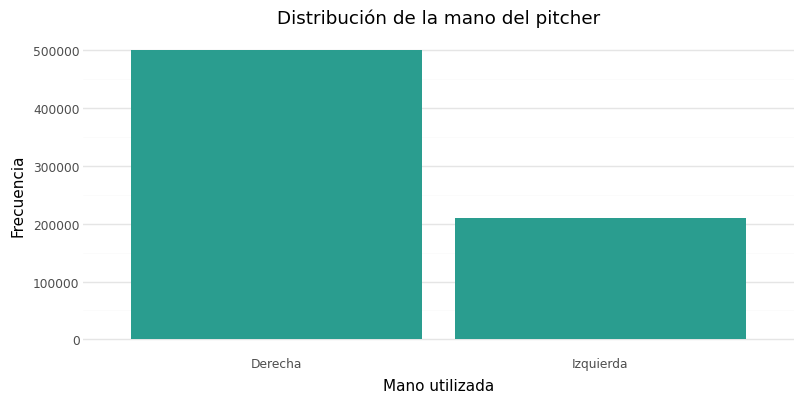

In [30]:
# Se filtra la variable mano del pitcher
freq_throws = (
    datos_entrenamiento
    .filter(pl.col("p_throws").is_not_null())
    .group_by("p_throws")
    .len()
    .sort("p_throws")
    .to_pandas()
)

# Se renombran las categorias solo para el gráfico
freq_throws["p_throws"] = freq_throws["p_throws"].replace({
    "L": "Izquierda",
    "R": "Derecha"
})

# Se arma el gráfico
(
    ggplot(freq_throws,
           aes(x="p_throws", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Distribución de la mano del pitcher",
        x="Mano utilizada",
        y="Frecuencia"
    )
    + theme_minimal()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank()
    )
)

En la variable mano del pitcher (`p_throws`) se evidencia una marcada diferencia entre las categorías, siendo los lanzadores derechos los que registran la mayor frecuencia dentro del conjunto de datos.

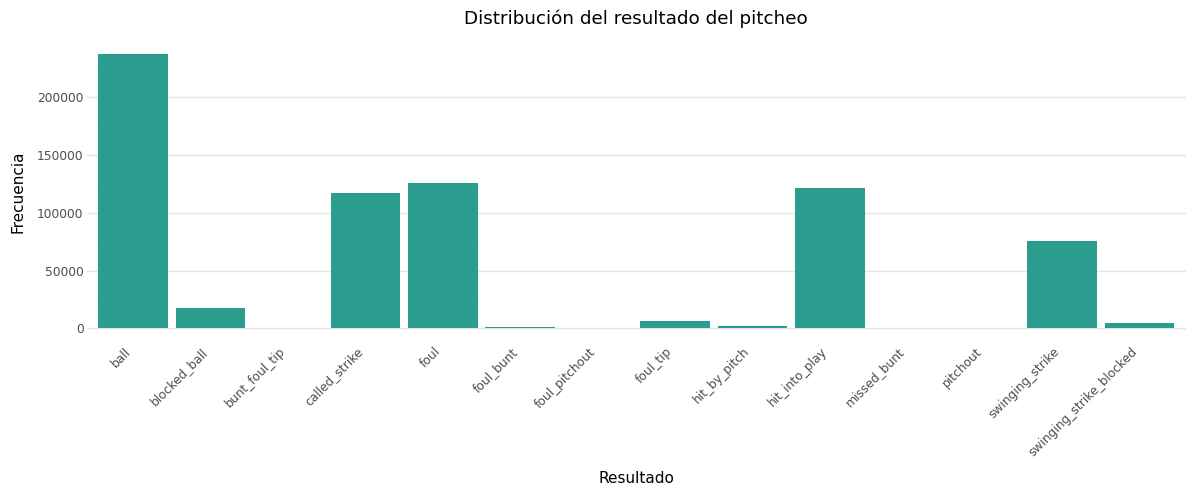

In [31]:
# Se filtra la variable resultado del pitcheo
freq_description = (
    datos_entrenamiento
    .filter(pl.col("description").is_not_null())
    .group_by("description")
    .len()
    .sort("description")
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(freq_description,
           aes(x="description", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Distribución del resultado del pitcheo",
        x="Resultado",
        y="Frecuencia"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 5),
        axis_text_x=element_text(rotation=45, hjust=1),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank()
    )
)

En el grafico anterior, de la variable resultado del pitcheo (`description`), se observa una marcada concentración de observaciones en unas pocas categorías. En particular, `ball` es la categoría más frecuente, seguida por `called_strike`, `foul` y `hit_into_play`. Por otro lado, varias categorías presentan frecuencias considerablemente menores, e incluso algunas aparecen de forma muy poco frecuente dentro del conjunto de datos.

SE PUEDE HACER UNA MATRIZ DE CORRELACIONES PARA LAS VARIABLES CUANTITATIVAS, HACER GRAFICOS DE DISPERSION SEGUN ALGUNAS CATEGORIAS. 
VER QUE MAS SE PUEDE HACER Y ANALIZAR EN ESTA SECCION !!